In [1]:
import pandas as pd             # Import the Pandas framework for DataFrame manipulation
import numpy as np              # Import the Numpy framework to handle numeric operations
import seaborn as sns           # Import Seaborn for statistical visualizations
import matplotlib.pyplot as plt # Import Matplotlib for plotting
from scipy.stats import spearmanr 

pd.set_option('display.max_rows', None)         # Pandas setting to show all rows with inspection commands
pd.set_option('display.max_columns', None)      # Pandas setting to show all columns with inspection commands
pd.set_option('display.max_info_columns', 200)  # Pandas setting to show info for 200 columns with the '.info()' command

df = pd.read_parquet('../../data/processed/crimes_features.parquet') # Create the variable 'df' containing the
                                                                      # enriched dataset produced by 04_feature_engineering.ipynb
df.head() # Display the first 5 rows to recall the DataFrame's columns

,DR_NO,Date Rptd,DATE OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,LOCATION,LAT,LON,hour_occ,year,month,day_of_week,hour_bins,age_group,crime_category,report_delay,is_domestic
0,1307355,2010-02-20,2010-02-20,13,Newton,1385,2,900,VIOLATION OF COURT ORDER,0913 1814 2000,48.0,M,H,501.0,SINGLE FAMILY DWELLING,0.0,No Weapon,AA,Adult Arrest,900.0,300 E GAGE AV,33.9825,-118.2695,13,2010,2,Saturday,Afternoon,Adult,person,0,False
1,11401303,2010-09-13,2010-09-12,14,Pacific,1485,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",0329,NaN,M,W,101.0,STREET,0.0,No Weapon,IC,Invest Cont,740.0,SEPULVEDA BL,33.9599,-118.3962,0,2010,9,Sunday,Night,NaN,property,1,False
2,70309629,2010-08-09,2010-08-09,13,Newton,1324,2,946,OTHER MISCELLANEOUS CRIME,0344,NaN,M,H,103.0,ALLEY,0.0,No Weapon,IC,Invest Cont,946.0,1300 E 21ST ST,34.0224,-118.2524,15,2010,8,Monday,Afternoon,NaN,other,0,False
3,90631215,2010-01-05,2010-01-05,6,Hollywood,646,2,900,VIOLATION OF COURT ORDER,1100 0400 1402,47.0,F,W,101.0,STREET,102.0,HAND GUN,IC,Invest Cont,900.0,CAHUENGA BL,34.1016,-118.3295,1,2010,1,Tuesday,Night,Adult,person,0,False
4,100100501,2010-01-03,2010-01-02,1,Central,176,1,122,"RAPE, ATTEMPTED",0400,47.0,F,H,103.0,ALLEY,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,122.0,8TH ST,34.0387,-118.2488,21,2010,1,Saturday,Late Night,Adult,person,1,False


# 09 — EDA Block 5: Response Effectiveness

**PACE Phase**: Analyze
**Objective**: analyze the effectiveness of law enforcement response
through the clearance rate (case resolution rate) and the report
delay (delay in reporting crimes).

**Input**: `data/processed/crimes_features.parquet`

**Research questions addressed**:
- Q5.1 — Clearance rate by crime category and by LAPD area
- Q5.2 — Report delay analysis: distribution and pattern by category

### Q5.1 — Clearance Rate by crime category

In [2]:
q51_df = df[['AREA NAME', 'Status Desc', 'crime_category']].copy() # Keep only the columns needed for the Q5.1 analyses

print(q51_df.head(10))

   AREA NAME   Status Desc crime_category
0     Newton  Adult Arrest         person
1    Pacific   Invest Cont       property
2     Newton   Invest Cont          other
3  Hollywood   Invest Cont         person
4    Central   Invest Cont         person
5    Central  Adult Arrest       property
6    Central   Invest Cont       property
7    Central  Adult Arrest         person
8    Central   Invest Cont         person
9    Central   Invest Cont       property


In [3]:
q51_df['Status Desc'].unique() # Display all distinct case statuses, to decide which ones count as "cleared"

array(['Adult Arrest', 'Invest Cont', 'Adult Other', 'Juv Arrest',
       'Juv Other', 'UNK'], dtype=object)

In [4]:
cleared_statuses = ['Adult Arrest', 'Juv Arrest', 'Adult Other', 'Juv Other'] # Statuses considered "case resolved"
q51_df['is_cleared'] = q51_df['Status Desc'].isin(cleared_statuses) # Boolean flag: True if the case was cleared

q51_df_area = (
    q51_df
    .groupby(['AREA NAME', 'is_cleared'], as_index=False)
    .agg(count = ('AREA NAME', 'count')) # Count records per area and clearance status
)

q51_df_category = (
    q51_df
    .groupby(['crime_category', 'is_cleared'], as_index=False)
    .agg(count = ('crime_category', 'count')) # Count records per macro-category and clearance status
)

print('AREA DATAFRAME')
print(q51_df_area.head(15))
print('========')
print('CATEGORY DATAFRAME')
print(q51_df_category.head(15))

AREA DATAFRAME
      AREA NAME  is_cleared   count
0   77th Street       False  161779
1   77th Street        True   45214
2       Central       False  138354
3       Central        True   29489
4    Devonshire       False  108936
5    Devonshire        True   29147
6      Foothill       False   84152
7      Foothill        True   28792
8        Harbor       False   96810
9        Harbor        True   36520
10   Hollenbeck       False   88286
11   Hollenbeck        True   26732
12    Hollywood       False  123523
13    Hollywood        True   27827
14      Mission       False  101609
CATEGORY DATAFRAME
  crime_category  is_cleared    count
0          other       False    30012
1          other        True    17636
2         person       False   598428
3         person        True   494596
4       property       False  1764178
5       property        True   174574


In [5]:
area_pivot = q51_df_area.pivot(index='AREA NAME', columns='is_cleared', values='count').fillna(0) # Reshape into
                                                                                                   # one row per area with True/False count columns
area_pivot['clearance_rate'] = area_pivot[True] / (area_pivot[True] + area_pivot[False]) * 100 # Share of cleared cases, in %
area_pivot = area_pivot.round(2).reset_index()
area_pivot = area_pivot.sort_values('clearance_rate', ascending = False)
print(area_pivot)

is_cleared    AREA NAME   False   True  clearance_rate
19          West Valley   94544  37102           28.18
4                Harbor   96810  36520           27.39
17             Van Nuys  103579  38927           27.32
13              Rampart   99712  36724           26.92
8           N Hollywood  121622  43198           26.21
11              Olympic  100314  35603           26.19
3              Foothill   84152  28792           25.49
7               Mission  101609  32090           24.00
16              Topanga   98566  30835           23.83
5            Hollenbeck   88286  26732           23.24
15            Southwest  149566  43164           22.40
0           77th Street  161779  45214           21.84
10            Northeast  112395  30697           21.45
14            Southeast  119459  32038           21.15
2            Devonshire  108936  29147           21.11
9                Newton  121327  27770           18.63
20             Wilshire  111254  25472           18.63
6         

In [6]:
category_pivot = q51_df_category.pivot(index='crime_category', columns='is_cleared', values='count').fillna(0) # Reshape into
                                                                                                                # one row per category with True/False count columns
category_pivot['clearance_rate'] = category_pivot[True] / (category_pivot[True] + category_pivot[False]) * 100 # Share of cleared cases, in %
category_pivot = category_pivot.round(2).reset_index()

print(category_pivot)

is_cleared crime_category    False    True  clearance_rate
0                   other    30012   17636           37.01
1                  person   598428  494596           45.25
2                property  1764178  174574            9.00


In [7]:
area_volume = area_pivot[True] + area_pivot[False] # Total crimes per area (cleared + not cleared)
rho_area, pval_area = spearmanr(area_volume, area_pivot['clearance_rate']) # Rank correlation: volume vs clearance rate

print(f'Spearman rho: {rho_area:.4f}')
print(f'p-value:      {pval_area:.4f}')

Spearman rho: -0.4638
p-value:      0.0342


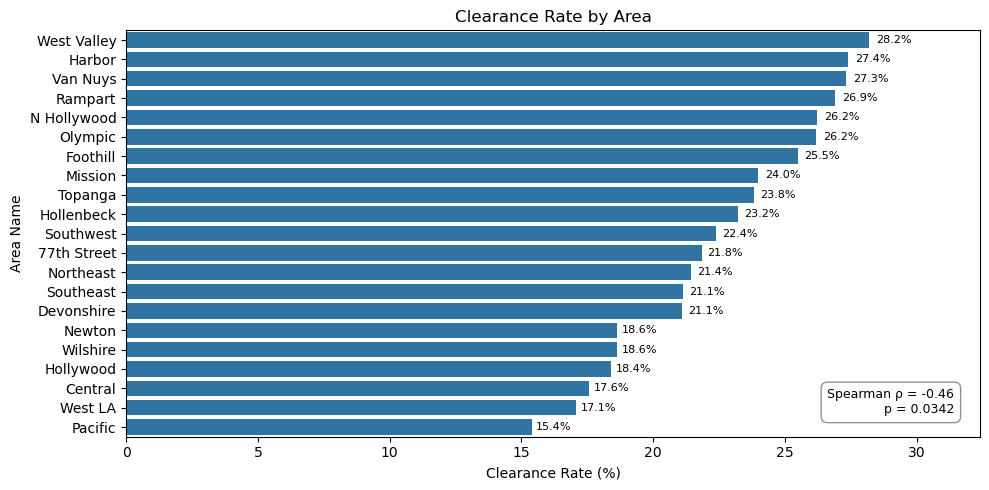

In [8]:
fig, ax = plt.subplots(figsize=(10, 5)) # Create the figure
bars = sns.barplot(
    data=area_pivot,
    x='clearance_rate',
    y='AREA NAME',
    ax=ax
)
for bar, value in zip(ax.patches, area_pivot['clearance_rate']): # Add a value label at the end of each bar
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center', ha='left',
        fontsize=8
    )
ax.text( # Annotate the rank correlation between crime volume and clearance rate
    0.97, 0.05,
    f'Spearman ρ = {rho_area:.2f}\np = {pval_area:.4f}',
    transform=ax.transAxes, # Axes coordinates: 0-1 range, independent of data scale
    ha='right', va='bottom',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.85)
)
ax.margins(x=0.15)
ax.set_title('Clearance Rate by Area')
ax.set_xlabel('Clearance Rate (%)')
ax.set_ylabel('Area Name')
plt.tight_layout()
plt.savefig('../../outputs/09_eda_block5/29_barh_clearance_rate_by_area.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q5.1 — Clearance Rate by LAPD area

The overall clearance rate ranges between 15.4% (Pacific) and 28.2%
(West Valley), with a range of only ~13 percentage points between the
best and worst areas.

**Areas with the highest clearance rate**:
- West Valley: 28.2%
- Harbor: 27.4%
- Van Nuys: 27.3%
- Rampart: 26.9%

**Areas with the lowest clearance rate**:
- Pacific: 15.4%
- West LA: 17.1%
- Central: 17.6%
- Hollywood: 18.4%

**Notable finding**: the areas with the highest crime volume in the previous blocks 
(77th Street, Southeast, Southwest) sit in the middle of the clearance rate ranking 
(21.8%, 21.2%, 22.4%). Across the 21 areas as a whole, however, Spearman's ρ = -0.46 (p = 0.034) 
indicates a moderate negative correlation between total crime volume and clearance rate.

**Methodological note**: the narrow range between areas (~13 points)
suggests that the clearance rate is influenced mainly by the
type of crime present in each area rather than by local investigative
effectiveness. The chart by crime category that follows
will clarify this point.

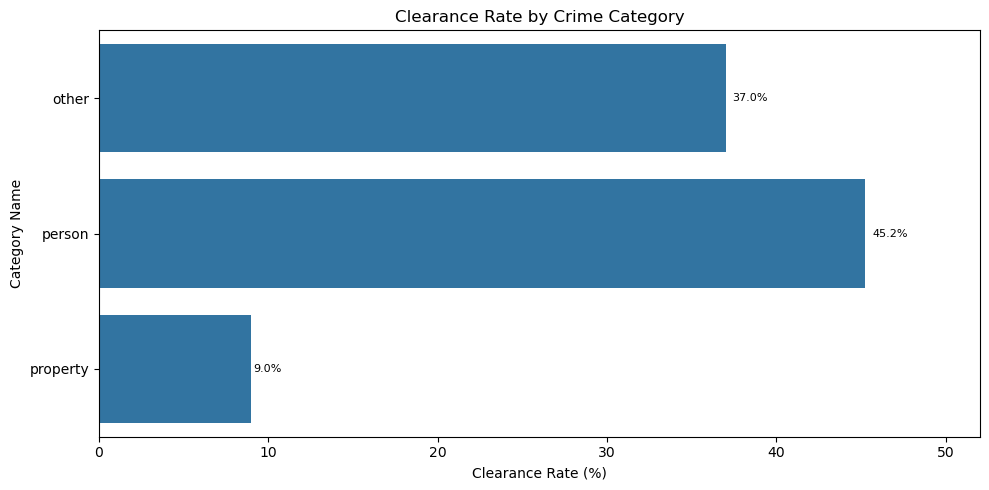

In [9]:
fig, ax = plt.subplots(figsize=(10, 5)) # Create the figure

bars = sns.barplot(
    data=category_pivot,
    x='clearance_rate',
    y='crime_category',
    ax=ax
)

for bar, value in zip(ax.patches, category_pivot['clearance_rate']): # Add a value label at the end of each bar
    ax.text(
        bar.get_width() + bar.get_width() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{value:.1f}%',
        va='center', ha='left',
        fontsize=8
    )

ax.margins(x=0.15)
ax.set_title('Clearance Rate by Crime Category')
ax.set_xlabel('Clearance Rate (%)')
ax.set_ylabel('Category Name')

plt.tight_layout()
plt.savefig('../../outputs/09_eda_block5/30_barh_clearance_rate_by_crime_category.png', dpi=150, bbox_inches='tight') # Save the chart
plt.show()

### Observations Q5.1 — Clearance Rate by crime category

- **Person**: 45.2% — almost half of crimes against the person are resolved.

- **Other**: 37.0% — a residual category with an intermediate clearance rate.

- **Property**: 9.0% — only 1 in 11 crimes against property is resolved.

**Key finding**: the gap between Person and Property is over 36 percentage points — the clearance rate for crimes against the person is 5 times higher than for crimes against property.

**Connection to the previous chart**: this finding explains the narrow range observed in the clearance rate by area. Since Property crimes account for approximately 60% of the dataset, their low resolution rate structurally compresses the overall clearance rate of all areas, regardless of local investigative effectiveness.

**Methodological note**: the clearance rate measures the percentage of cases in which a suspect was identified and charged. A low rate does not necessarily indicate poor investigative performance — it reflects the structural characteristics of each crime category and should be contextualized before drawing conclusions about law enforcement effectiveness.

### Q5.2 - Report delay analysis

In [10]:
q52_df = df[['report_delay', 'crime_category']].copy() # Keep only the columns needed for the Q5.2 analyses
q52_df = q52_df[q52_df['report_delay'] <= 365] # Exclude delays over a year: exceptional cases that would
                                                # distort the distribution
q52_df = q52_df[q52_df['report_delay'] >= 0]   # Exclude negative delays (data entry errors)
print(q52_df.shape)
print(q52_df['report_delay'].describe().round(2))

(3040664, 2)
count    3040664.00
mean           7.37
std           29.82
min            0.00
25%            0.00
50%            1.00
75%            2.00
max          365.00
Name: report_delay, dtype: float64


In [11]:
q52_df_filtered = q52_df[(q52_df['crime_category'] != 'other') & (q52_df['report_delay'] <= 30)].copy()
# Keep only Person/Property crimes with a report delay of 30 days or less, to focus the mean/median
# comparison on the bulk of the distribution without long-tail outliers pulling the mean up

q52_stats = q52_df_filtered.groupby('crime_category')['report_delay'].agg(['mean', 'median']).round(1) # Mean and
                                                                                                        # median delay per category
print(q52_stats)

                mean  median
crime_category              
person           1.0     0.0
property         2.5     1.0


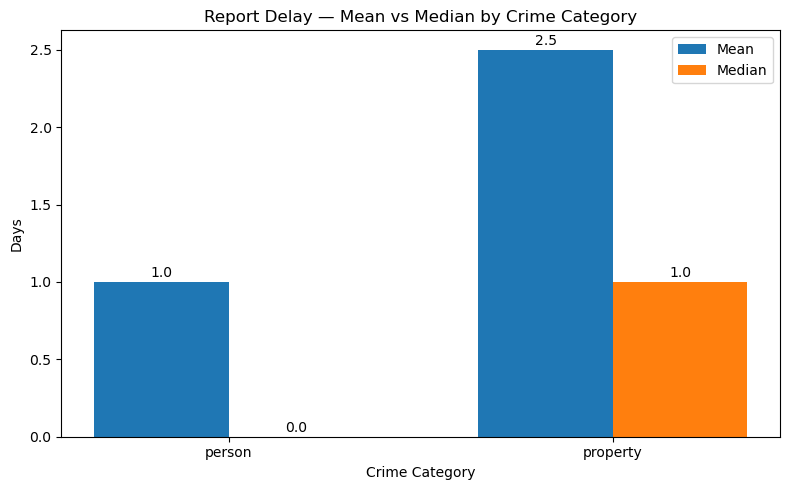

In [12]:
categories = q52_stats.index.tolist()   # Category names, from the groupby index
means = q52_stats['mean'].tolist()      # Mean delay per category
medians = q52_stats['median'].tolist()  # Median delay per category

x = np.arange(len(categories)) # Numeric x positions, one per category
width = 0.35                   # Bar width, so mean/median bars sit side by side without overlapping

fig, ax = plt.subplots(figsize=(8, 5)) # Create the figure
ax.bar(x - width/2, means, width, label='Mean')
ax.bar(x + width/2, medians, width, label='Median')

for bar in ax.patches: # Add a value label above each bar
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{bar.get_height():.1f}',
        ha='center', va='bottom', fontsize=10
    )

ax.set_title('Report Delay — Mean vs Median by Crime Category')
ax.set_xlabel('Crime Category')
ax.set_ylabel('Days')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
plt.savefig('../../outputs/09_eda_block5/31_barplot_report_delay_mean_median.png', dpi=150, bbox_inches='tight') # Save the chart
plt.tight_layout()
plt.show()

In [13]:
total = len(df[df['crime_category'] != 'other'])   # All Person/Property records, regardless of report delay
filtered = len(q52_df_filtered)                     # Person/Property records with a delay of 30 days or less
excluded = total - filtered                         # Records with a delay over 30 days (or outside 0-365, already dropped above)
print(f'Total records: {total:,}')
print(f'Filtered records (<=30 days): {filtered:,}')
print(f'Excluded records (>30 days): {excluded:,}')
print(f'Excluded percentage: {excluded/total*100:.1f}%')

Total records: 3,031,776
Filtered records (<=30 days): 2,834,639
Excluded records (>30 days): 197,137
Excluded percentage: 6.5%


### Observations Q5.2 — Report Delay by crime category

**Methodological note**: the analysis is limited to crimes with a report delay
between 0 and 365 days (3,040,664 records). Cases with a delay longer
than a year represent exceptional situations, excluded to maintain
statistical significance. The comparison by category excludes "Other"
and covers 3,031,776 total records, of which 2,834,639 with a delay ≤ 30 days
(93.5%) and 197,137 with a delay between 31 and 365 days (6.5%).

**Crimes against the person**:
- Mean: 1.0 day
- Median: 0.0 days — reported the same day they occur

**Crimes against property**:
- Mean: 2.5 days
- Median: 1.0 day

**General pattern**: both categories show very limited delays — 75% of all crimes are reported within 2 days of the event.

**Difference between categories**: crimes against the person are reported more quickly than crimes against property — mean of 1.0 day vs 2.5 days, median of 0.0 vs 1.0 day.